# Transfermarkt data exploration and cleaning

### Introduction:
In this notebook, I will clean and explore the data from **Transfermarkt**!

### About the data:
The data is taken from Kaggle -> [Football Data from Transfermarkt](https://www.kaggle.com/datasets/davidcariboo/player-scores), from which comes the **appearances, competitions, game_events, game_lineups, games and transfers** data and from the [5.7M+ Records -Most Comprehensive Football Dataset](https://www.kaggle.com/datasets/xfkzujqjvx97n/football-datasets) comes the **player_injuries** data!

Both of data sources provide data from [Transfermaekt](https://www.transfermarkt.com/), which is a globally trusted football platform, which provides all kinds of data, including matches data, players data and especially players transfers data!

### Data description:
| dataset | description |
| -------- | ------- |
| **competitions**  | Leagues and tournaments tracked in the dataset |
| **appearances** | One row per player per game, with goals, assists and cards |
| **games** | One row per game, with scores, attendance and referee |
| **game_lineups** | Starting and bench lineups per game |
| **transfers** | Player transfers between clubs with fees |
| **player_injuries** | Players injuries with the date range of the injury |


### Why this dataset:
I chose to work with this dataset, because it provides very detailed players and transfers data, which I mainly plan to use under the form of **player influence** over the matches!The missing of key players is a very big factor which higly affects the teams performances and the outcomes of the matches.The **player influence factor** is not only about **missing** players, but also relates to the ones which are **available** during the games and more importantly the best ones!So the process of identifing the most important and key players among the matches and effect of the ones which are missing, is something very important for the matches and the prediction of their outcomes!

Something else which is very important is the different competitions in which the teams invlove with.For example a team can play in more than one competition in the same moment and it is very important to consider the fact that certain competitions are much more important than others!This would mean that a match can have either, a very big importance or a very less importance, depending on the competition and aims of the teams.Fortunately, this data provides info about many different competitions and I will take advantage from that!

### Cloude storage:
The data is loaded directly from google cloude!

The script which loads the data: [cloude_storage](../../src/football_betting_analysis/data/cloude_storage/load_gcs_datasets.py)

#### Foreknowledge of the data:
From what I have observed from the data, I expect that the **id's of the players** in the datasets are connected and shared amoung all of the different data.This is extremely important, because if there is inconsistency between the players id's among the datasets I will not be able to use the dataset in any meaningful way!

### Plan and work process:
The datasets are a lot, and I will not try to clean them all, unless it is fully required, but I do everything which is required to get the player data needed for the creation of the players infuence features!In short, I will clean and explore only the data which is needed for the purpose of this notebook.All of this is because I haven't explored the data and I don't know what to expect from it!

However, my main attention will be over the `games, game_lineups` and `player_injuries` datasets, which provides the most essential data and are directly related to the aims of this notebook and to the aims of the peoject at all!

#### The datasets and their most important functions:
1.**GAMES**: \
This is the dataset which combines everything.At end everything should be on match level simply because we predict matches! 

Key features: **match date, teams, competition, attendance, formations, league positions**

2.**APPEARANCES**: \
Most important player dataset.This is where player importance will come from.

Key features: **minutes, goals, assists, cards**

3.**PLAYER_INJURIES**: \
Without this dataset I cannot construct the availability features.

Key features: **player_id, injury type, date ranges**

4.**GAME_LINEUPS**: \
The actual players available for the matches.This will be directly connected with the players injuries dataset!

Needed for:
- starters
- captain
- expected XI estimation
- identifying key players

5.**COMPETITIONS**: \
All of the available competitions. 

Needed for:
- identifying domestic leagues
    - Champions League
    - Europa League
    - cups

6.**TRANSFERS**: \
This dataset can be very useful for:
- identifying team's squad before the matches
- determining current club history
- teams total market values

#### Data cleaning:
I will clean the data, as much as I could by following a standard process such as:
- fixing the data types
- fixing any text or encoding probelms with the teams and players names
- mapping the teams names to the ones from the other datasets(**Understat**) - to maintain consistency!
- optimizing the datasets memory usage, as this means that some of the data types can be downcasted to more small-memory ones
- feature engineering
- Making all kinds of validations to ensure that the dataset meets all of the minimal requirements for the needs of the project!

Maybe the most important thing will be to **connect** the datasets in way that they can be used at **match level** and providing its data data under the form of **players influence and matches importance**!

#### Getting started:
Lets start with exploration and cleaning of the `games` dataset:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import unicodedata
from pathlib import Path

from football_betting_analysis.data.data_cleaning import convert_string_to_datetime, validate_and_cast_dataframe_dtypes, optimize_dataframe_memory
from football_betting_analysis.data.text_cleaning import clean_text_values
from football_betting_analysis.data.save_data_into_file import save_data

from football_betting_analysis.config import DATE_FORMAT, START_DATE, END_DATE, START_SEASON, END_SEASON, TRANSFERMARKT_DATA_INTERIM_PATH

In [2]:
games_df = pd.read_csv('../../data/raw/transfermarkt_data/games.csv')

In [3]:
games_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86983 entries, 0 to 86982
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 86983 non-null  int64  
 1   competition_id          86983 non-null  str    
 2   season                  86983 non-null  int64  
 3   round                   86983 non-null  str    
 4   date                    86983 non-null  str    
 5   home_club_id            86983 non-null  int64  
 6   away_club_id            86983 non-null  int64  
 7   home_club_goals         86983 non-null  int64  
 8   away_club_goals         86983 non-null  int64  
 9   home_club_position      61761 non-null  float64
 10  away_club_position      61761 non-null  float64
 11  home_club_manager_name  86139 non-null  str    
 12  away_club_manager_name  86139 non-null  str    
 13  stadium                 86742 non-null  str    
 14  attendance              76310 non-null  float64
 

In [4]:
games_df.columns

Index(['game_id', 'competition_id', 'season', 'round', 'date', 'home_club_id',
       'away_club_id', 'home_club_goals', 'away_club_goals',
       'home_club_position', 'away_club_position', 'home_club_manager_name',
       'away_club_manager_name', 'stadium', 'attendance', 'referee', 'url',
       'home_club_formation', 'away_club_formation', 'home_club_name',
       'away_club_name', 'aggregate', 'competition_type'],
      dtype='str')

The data is a lot because it contains matches data for many different competitions and leagues across the world.As we know, our project is focused only in the Spanish La Liga!And more specifically, the matches between the seasons: **2014/2015** - **2024/2025**!However, in order to be able to create features such as matches importance and observe other competiotins which can have a lot of impact over the matches, I will have to process more competitions than just the Spanish La Liga!

Now, in order to reduce the amount of data with which I will be working to, I need to check what types of competitions does this dataset contains.

I want to specify that, typically, one of the most important competitions for a team in La Liga, and not only, are the following:
- National duties like the World Cup or continental specific like Europe Cup or Copa America!
- Champions League
- League Europa
- Conference league
- Domestic Cup, which refers to cups specifically related to the country of the team!

> ALl of these competitions have higher priority than the La Liga mathces, except for the country specific domestic cups maybe![3]

So in order reduce the amount of data, we first need to identify which competitions are related to the Spanish La Liga teams and which are not.In order to do so, I will need the **competitions data**!

In [5]:
competitions_df = pd.read_csv('../../data/raw/transfermarkt_data/competitions.csv')

In [6]:
competitions_df.columns

Index(['competition_id', 'competition_code', 'name', 'sub_type', 'type',
       'country_id', 'country_name', 'domestic_league_code', 'confederation',
       'total_clubs', 'url'],
      dtype='str')

Lets see the unique types of the competitions:

In [7]:
competitions_df.type.unique()

<ArrowStringArray>
[          'domestic_league', 'national_team_competition',
                     'other',              'domestic_cup',
         'international_cup']
Length: 5, dtype: str

As I have expected, we have the **domestic_league**, which refers to leagues such as LaLiga, Premier League, Bundeslega etc, the **domestic_cup** which refers to the country specific cups such as Copa Del Rey for Spain and FA Cup for England, the **international_cup**, which refers to cups such as the Champions League, Europe legaue, Super Cup, the **national_team_competition** which refers to cups such as: FIFA World Cup, Europe cup etc and the **other** which from what I can see refers to the **uefa_conference_league** which can be assigned to the International cup group but it doesn't really matter!

Now, lets see all of the competitions confederations names:

In [8]:
competitions_df.confederation.unique()

<ArrowStringArray>
['europa', 'asien', 'afrika', 'amerika', 'fifa']
Length: 5, dtype: str

As the project is about the Spanish La Liga teams, which teams are from **europe**, I will keep the things down to **europe** and **fifa** just because we are not intereset in the other where the LaLiga teams does not participate!

However, we cannot take everything from the europe, because this includes the leagues of the other countries.What we want are the leagues related only for the Spanish LaLiga and also the cups which can be played from the spanish teams, which includes:
- UEFA Champions League
- UEFA Europa League
- UEFA Conference League
- UEFA Super Cup
- La Liga
- Copa Del Rey
- Spain Super Cup
- World Cup
- World Team cup
- Europe Cup

So lets take the id's of the competitions which are from europe or fifa as a confederation name and are directly related to the Spanish teams:

In [9]:
competitions_df[
    (
        (competitions_df.confederation == 'europa') |
        (competitions_df.confederation == 'fifa')
    ) &
    (
        (competitions_df.country_name == 'Spain') |
        competitions_df.country_name.isna()
    )
]

,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,total_clubs,url
9,CDR,copa-del-rey,copa-del-rey,domestic_cup,domestic_cup,157,Spain,ES1,europa,20.0,https://www.transfermarkt.co.uk/copa-del-rey/s...
12,CL,uefa-champions-league,uefa-champions-league,uefa_champions_league,international_cup,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-champions...
13,CLQ,uefa-champions-league-qualifying,uefa-champions-league-qualifying,uefa_champions_league_qualifying,international_cup,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-champions...
20,ECLQ,uefa-conference-league-qualifiers,uefa-conference-league-qualifiers,uefa_conference_league_qualifiers,other,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-conferenc...
21,EL,uefa-europa-league,uefa-europa-league,uefa_europa_league,other,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-europa-le...
22,ELQ,uefa-europa-league-qualifying,uefa-europa-league-qualifying,uefa_europa_league_qualifying,other,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-europa-le...
23,ES1,laliga,laliga,first_tier,domestic_league,157,Spain,ES1,europa,20.0,https://www.transfermarkt.co.uk/laliga/startse...
24,EURO,uefa-euro,uefa-euro,uefa_euro,national_team_competition,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-euro/star...
26,FIWC,world-cup,world-cup,world_cup,national_team_competition,-1,NaN,NaN,fifa,NaN,https://www.transfermarkt.co.uk/world-cup/star...
35,KLUB,fifa-klub-wm,fifa-klub-wm,fifa_club_world_cup,other,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/fifa-klub-wm/s...


In [10]:
target_competitions_ids = competitions_df[
    (
        (competitions_df.confederation == 'europa') |
        (competitions_df.confederation == 'fifa')
    ) &
    (
        (competitions_df.country_name == 'Spain') |
        competitions_df.country_name.isna()
    )
]['competition_id']

In [11]:
target_competitions_ids = target_competitions_ids.values.tolist()

In [12]:
target_competitions_ids

['CDR',
 'CL',
 'CLQ',
 'ECLQ',
 'EL',
 'ELQ',
 'ES1',
 'EURO',
 'FIWC',
 'KLUB',
 'SUC',
 'UCOL',
 'USC']

Now lets reduce the amount of games data, by leaving only the ones which are from the target competitions and also are from the seasons between 2014 and 2025.

In order to do that I need to convert the date feature into a **datetime** object so that I can filter the data between the seasons much more easily:

### Converting the date feature into datetime object:

I will use the `convert_string_to_datetime` function:

In [13]:
games_interim_df = games_df.copy()

In [14]:
games_interim_df['date'] = convert_string_to_datetime(datetime_series=games_interim_df['date'], format_string=DATE_FORMAT)

In [15]:
games_interim_df.date.info()

<class 'pandas.Series'>
RangeIndex: 86983 entries, 0 to 86982
Series name: date
Non-Null Count  Dtype         
--------------  -----         
86983 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 679.7 KB


Now lets reduce the data:

### Reducing the amount of data:

In [16]:
games_interim_df = games_interim_df[
    (games_interim_df.competition_id.isin(target_competitions_ids)) &
    (games_interim_df.date >= START_DATE) &
    (games_interim_df.date <= END_DATE)
]

In [17]:
games_interim_df.shape

(13788, 23)

We can see how much the dataset has been reduced!This is because, currently the dataset is containing matches only related to the Spanish football plus matches from the Europian cups and also from the international ones!In fact the dataset also contains matches of teams which are not from the Spanish La Liga and are not related to out study objective, but this none of a problem, because in the end we will end up with the standard amount of matches which are, from what I know and expect, **4,180** total matches, only related to the **Spanish La Liga** - This will happen only after all of the features about player influence and match importance have been created, and for this to happen we need all of the data!

For now, I will proceed by cleaning the data that we got, using the standard cleaning process.I will make some validations and explore the data more detaily this time, because we have a lot of matches and I want to ensure that everything is perfectly cleaned and ready for processing and feature engineering!

I suppose that we are ready to start:
## Cleaning and exploring the data:

In [18]:
games_interim_df.info()

<class 'pandas.DataFrame'>
Index: 13788 entries, 12744 to 79211
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   game_id                 13788 non-null  int64         
 1   competition_id          13788 non-null  str           
 2   season                  13788 non-null  int64         
 3   round                   13788 non-null  str           
 4   date                    13788 non-null  datetime64[us]
 5   home_club_id            13788 non-null  int64         
 6   away_club_id            13788 non-null  int64         
 7   home_club_goals         13788 non-null  int64         
 8   away_club_goals         13788 non-null  int64         
 9   home_club_position      4180 non-null   float64       
 10  away_club_position      4180 non-null   float64       
 11  home_club_manager_name  13720 non-null  str           
 12  away_club_manager_name  13720 non-null  str           
 13

There are a lot of missing values, but what I expect is that they are not from the actual La Liga matches, because this would be very bad!

Actually lets see the missing values specially from the LaLiga matches:

In [19]:
games_interim_df[
    games_interim_df.competition_id == 'ES1'
].info()

<class 'pandas.DataFrame'>
Index: 4180 entries, 12795 to 74773
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   game_id                 4180 non-null   int64         
 1   competition_id          4180 non-null   str           
 2   season                  4180 non-null   int64         
 3   round                   4180 non-null   str           
 4   date                    4180 non-null   datetime64[us]
 5   home_club_id            4180 non-null   int64         
 6   away_club_id            4180 non-null   int64         
 7   home_club_goals         4180 non-null   int64         
 8   away_club_goals         4180 non-null   int64         
 9   home_club_position      4180 non-null   float64       
 10  away_club_position      4180 non-null   float64       
 11  home_club_manager_name  4180 non-null   str           
 12  away_club_manager_name  4180 non-null   str           
 13 

Well, here there are also missing values.I will deal with them later!

In [20]:
games_interim_df.describe().T

,count,mean,min,25%,50%,75%,max,std
game_id,13788.0,3386443.312953,2470376.0,2866206.75,3252541.5,3901582.5,4604198.0,623212.15191
season,13788.0,2019.261169,2014.0,2017.0,2019.0,2022.0,2024.0,3.154131
date,13788,2020-02-20 12:45:13.315927,2014-08-05 00:00:00,2017-07-02 18:00:00,2020-02-09 00:00:00,2022-11-02 00:00:00,2025-05-31 00:00:00,NaN
home_club_id,13788.0,5438.805411,3.0,366.0,932.0,3556.0,121966.0,12043.768772
away_club_id,13788.0,4584.302582,3.0,366.0,865.0,3368.0,123045.0,10309.962483
home_club_goals,13788.0,1.62054,0.0,1.0,1.0,2.0,15.0,1.468527
away_club_goals,13788.0,1.290615,0.0,0.0,1.0,2.0,15.0,1.347357
home_club_position,4180.0,10.401435,1.0,5.0,10.0,15.0,20.0,5.754954
away_club_position,4180.0,10.598565,1.0,6.0,11.0,16.0,20.0,5.777281
attendance,12191.0,22491.382659,10.0,6799.5,16552.0,34040.0,99354.0,19901.107874


From the summary statistic table above I cannot see something which is wrong or very extreme as a value, except maybe the min value of the **attendance** feature.It is not possible for matches at this level, at these competitions to have a match with such small attendance!The only thing which comes to my mind, as a possible reason for this value is the pandemic that broke out during the **Covid virus**, which accordingly prohibited any attendance at football matches.

### Observing the attendance feature:
From what wikipedia[1.1] says about the impact of the **coronavirus** over the football matches, the affected matches were in season **2019/2020 and 2020/2021** and more specifically the limitaions have begun in **early/mid-March 2020** and lasted until limited capacities or full stadium crowds returned between **May and July 2021**!

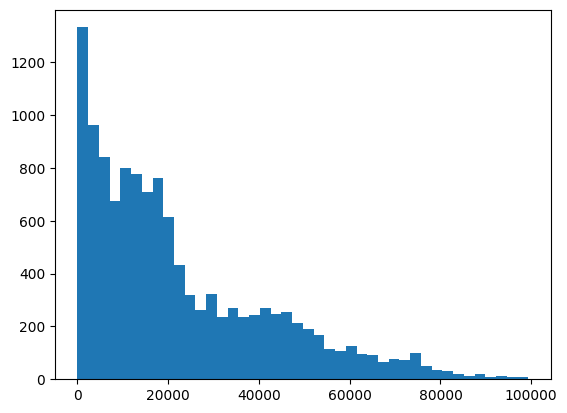

In [21]:
plt.hist(games_interim_df.attendance, bins='fd')
plt.show()

In [22]:
games_interim_df[games_interim_df.attendance.isna()]['season'].value_counts()

season
2020    937
2019    151
2021     92
2015     84
2024     81
2016     62
2017     60
2018     50
2014     48
2023     24
2022      8
Name: count, dtype: int64

In [23]:
len(games_interim_df[
    (
        (games_interim_df.season == 2019) |
        (games_interim_df.season == 2020) |
        (games_interim_df.season == 2021)
    ) &
    (games_interim_df.attendance.isna())
])

1180

The total missing values:

In [24]:
len(games_interim_df[
    games_interim_df.attendance.isna()
])

1597

Well, a very big part of the missing values come from the season 2019, 2020 and 2021, exactly when it was the peak of the Covid virus!

One thing which could be done is to fill all this missing values with zeros, just because this is the only right value which could be put.Anyway, there are about 500 more matches with missing attendance values which currently, I cannot understand what could have caused them to be like that but anyway.

What I care about are the matches from LaLiga because they are the project target and the ones which will be predicted, so lets see if there are any matches with missing values which are not from the covid range seasons:

In [25]:
games_interim_df[
    (games_interim_df.competition_id == 'ES1') &
    (games_interim_df.attendance.isna())
].season.value_counts()

season
2020    375
2019    111
2017      1
Name: count, dtype: int64

Well, we can clearly see that the missing attendances comes exactly from the expected seasons, except one which is from **2017** - this match will be handled individually with research!

> However, from now I can state that the best possible imputation approach for these missing values will be to fill them up with zeros, because this is the only right value!And this is what I plan to do!

By the way if you wonder why the season 2021 does not appear in the list of missing values, this is because the **season** feature of the dataset includes only the start year of the season and not the end.What I want to specify is that the **season 2020** as a season value from the dataset also includes matches from 2021!

And actually, there are no matches from year **2019** which are without attendance, which is what we expect, because from what **wikipedia**[1.1] says: *"In Europe, various knockout matches in the Champions League and Europa League were played behind closed doors in February and March 2020"* and *"Many of the domestic European leagues were impacted in February and March 2020"*

We can see that:

In [26]:
games_interim_df[
    (games_interim_df.competition_id == 'ES1') &
    (games_interim_df.attendance.isna())
].date.dt.year.value_counts()

date
2020    266
2021    220
2017      1
Name: count, dtype: int64

With this addition, everything seems to be perfectly clear!So lets impute the the missing values:

### Imputing attendance missing values:
I will impute with zeros all of the missing values from season 2019 and 2020, without including the one from 2017 because this is another case!

In [27]:
games_interim_df.loc[
    (games_interim_df.competition_id == 'ES1') &
    (games_interim_df.season.isin([2019, 2020])) &
    (games_interim_df.attendance.isna()),
    'attendance'
] = 0

Now everything is perfect!

Now, lets see what is the case with the match from season 2017:

In [28]:
games_interim_df[
    (games_interim_df.competition_id == 'ES1') &
    (games_interim_df.attendance.isna())
]

,game_id,competition_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,...,stadium,attendance,referee,url,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type
31826,2899620,ES1,2017,7. Matchday,2017-10-01,131,472,3,0,1.0,...,Spotify Camp Nou,NaN,José Luis Munuera Montero,https://www.transfermarkt.co.uk/fc-barcelona_u...,4-4-2,4-2-3-1,Futbol Club Barcelona,UD Las Palmas,3:0,domestic_league


The actual reason why this match has been played without attendance is that at that time, there has been a protest after Barcelona's request for it to be postponed in light of Catalonia's independence referendum was rejected![4]!

So because of this reason, I think that, again,  the most logical think would be to fill in this missing value with zero!

In [29]:
games_interim_df.loc[games_interim_df.game_id == 2899620, 'attendance'] = 0

In [30]:
games_interim_df[
    (games_interim_df.competition_id == 'ES1') &
    (games_interim_df.attendance.isna())
]

,game_id,competition_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,...,stadium,attendance,referee,url,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type


Ok, we have imputed all of the missing values of the attendance feature.If you wonder why I didn't do the same for all of the other matches of the other competitions, is because it doesn't really matter!I will use the data from the other competitions matches only for the feature engineering which engineering does not include the **attendance** in any way!What the engineering will include, are features mainly related to the **matches importance** and **player availability**, as there are a lot of teams which have played without their key players due to the fact that these players could have been on international duties!

And if you wonder why I spent so much time dealing with the attendance feature, it is simply because the feature will play a very big role into something which I would define as **team presure**.The team presure can be derived from many thing really, but the one which is really important is exactly the attendance during the matches.Why?Because there are very **calm** matches, but also there are very **high presure** matches!Also the attendance as a feature can identity the **match importance** at all, because it is logical for the more important match to have more people watch it!And of course there are many feature which could be structured from this feature, but for this later!

Now lets proceed with the data cleaning.
### Fixing the data types
Some of the feature are with unsuitable data types.This should be fixed!

In [31]:
games_interim_df.dtypes

game_id                            int64
competition_id                       str
season                             int64
round                                str
date                      datetime64[us]
home_club_id                       int64
away_club_id                       int64
home_club_goals                    int64
away_club_goals                    int64
home_club_position               float64
away_club_position               float64
home_club_manager_name               str
away_club_manager_name               str
stadium                              str
attendance                       float64
referee                              str
url                                  str
home_club_formation                  str
away_club_formation                  str
home_club_name                       str
away_club_name                       str
aggregate                            str
competition_type                     str
dtype: object

In [32]:
games_interim_df = validate_and_cast_dataframe_dtypes(games_interim_df)

In [33]:
games_interim_df.dtypes

game_id                            int64
competition_id                       str
season                             int64
round                                str
date                      datetime64[us]
home_club_id                       int64
away_club_id                       int64
home_club_goals                    int64
away_club_goals                    int64
home_club_position                 Int64
away_club_position                 Int64
home_club_manager_name               str
away_club_manager_name               str
stadium                              str
attendance                         Int64
referee                              str
url                                  str
home_club_formation                  str
away_club_formation                  str
home_club_name                       str
away_club_name                       str
aggregate                            str
competition_type                     str
dtype: object

### Removing features
I will remove some of the features which do not provide any meaningful info which could be used for the aims of the project!Such features are the match `url` and `aggregate` features.

The `url` feature is the link for the specific match in the `Transfermarkt` platform. \
The `aggragate` feature is the result of the match represented in the format: home_goals : away_goals, which is useless when we alreday have the home and away total match goals!

So lets remove them:

In [34]:
games_interim_df = games_interim_df.drop(columns=['url', 'aggregate'])

In [35]:
games_interim_df.columns

Index(['game_id', 'competition_id', 'season', 'round', 'date', 'home_club_id',
       'away_club_id', 'home_club_goals', 'away_club_goals',
       'home_club_position', 'away_club_position', 'home_club_manager_name',
       'away_club_manager_name', 'stadium', 'attendance', 'referee',
       'home_club_formation', 'away_club_formation', 'home_club_name',
       'away_club_name', 'competition_type'],
      dtype='str')

### Dealing with the text features
From what I had observed from the dataset, the **teams names** are presented in a very country specific way, which contains very specific.This will be a problem when I later map the teams names from this dataset to the others, so they should be fixed and normalized into more general unicode symbols!However, for now I will not perform such normalization, just because I will first need to connect the different datasets and feature engineer some features, and right after that I will think what can be done and how I should deal with them.

Now I will just use the `clean_text_values` function which will make a more surface cleaning by removing any white spaces, hidden characters and fix common punctuation like curly quotes, dashes and ellipses within standard characters.

In [36]:
text_features = games_interim_df.select_dtypes(include=['str']).columns.tolist()
games_interim_df[text_features] = games_interim_df[text_features].apply(
    clean_text_values
)

### Optimizing the dataset memory usage:
Using the `optimize_dataframe_memory` to reduce the memory usage of the dataset:

In [37]:
games_interim_df = optimize_dataframe_memory(games_interim_df)

Initial Memory Usage: 4.38 MB
Final Memory Usage: 1.16 MB
Memory Reduction: 73.46%

Optimized Data Types:
game_id                            int32
competition_id                  category
season                             int16
round                           category
date                      datetime64[us]
home_club_id                       int32
away_club_id                       int32
home_club_goals                     int8
away_club_goals                     int8
home_club_position                 Int64
away_club_position                 Int64
home_club_manager_name          category
away_club_manager_name          category
stadium                         category
attendance                         Int64
referee                         category
home_club_formation             category
away_club_formation             category
home_club_name                  category
away_club_name                  category
competition_type                category
dtype: object


### Dealing with the season feature
Currently the seasons are represented in a single year format which is wrong and will cause problems when the dataset is merged with the other ones, because all of the other datasets represent the matches seasons in format: `year/year + 1`!

So lets fix that:

In [38]:
games_interim_df['new_season'] = np.where(
    games_interim_df['date'].dt.month >= 8,
    games_interim_df['date'].dt.year.astype(str) + '/' + (games_interim_df['date'].dt.year + 1).astype(str),
    (games_interim_df['date'].dt.year - 1).astype(str) + '/' + games_interim_df['date'].dt.year.astype(str)
)

In [39]:
valid_seasons = [
    f"{year}/{year+1}" for year in range(START_SEASON, END_SEASON)
]

len(games_interim_df[games_interim_df['new_season'].isin(valid_seasons)]) == len(games_interim_df)

True

#### Replacing the new seasons values with old ones:

In [40]:
games_interim_df['season'] = games_interim_df['new_season']
games_interim_df = games_interim_df.drop(columns=['new_season'])

#### Ensuring that the matches from La Liga are equallally distributed across the seasons:

In [41]:
games_interim_df[
    games_interim_df.competition_id == 'ES1'
].groupby('season').size()

season
2014/2015    380
2015/2016    380
2016/2017    380
2017/2018    380
2018/2019    380
2019/2020    380
2020/2021    380
2021/2022    380
2022/2023    380
2023/2024    380
2024/2025    380
dtype: int64

Everything seems to be ok now!

Now lets cast the season feature into a category type: 

In [42]:
games_interim_df['season'] = games_interim_df['season'].astype('category')

Now everything seems to be perfect with season feature!

### Dealing with the `home_club_position` and `away_club_position` features

These two features are still into a very big dtype, but both of them contains values max up to **20** - which is the last team position in a typical football league. And currently these features are only related to **La Liga competition** which is the **first-division Spanish domestic league**, and it is logical these two features to have values only for this competition - All of the other competitions are not domestic and there are no defined places in them!**So this explains why there are only 4,180 non missing values in these features.**

However I will downcast the features into a more small-sized integer type: 

In [43]:
games_interim_df['home_club_position'] = pd.to_numeric(games_interim_df['home_club_position'], downcast='integer')
games_interim_df['away_club_position'] = pd.to_numeric(games_interim_df['away_club_position'], downcast='integer')

### Validating that there are no positions lower than 1 and higher than 20:

In [44]:
games_interim_df[
    games_interim_df.competition_id == 'ES1'
].groupby('season')[['home_club_position', 'away_club_position']].agg(['min', 'max'])

home_club_position     away_club_position    
                         min max                min max
season                                                 
2014/2015                  1  20                  1  20
2015/2016                  1  20                  1  20
2016/2017                  1  20                  1  20
2017/2018                  1  20                  1  20
2018/2019                  1  20                  1  20
2019/2020                  1  20                  1  20
2020/2021                  1  20                  1  20
2021/2022                  1  20                  1  20
2022/2023                  1  20                  1  20
2023/2024                  1  20                  1  20
2024/2025                  1  20                  1  20

Everything seems to be perfect with the positions features!

### Observing the games round feature:

The `round` feature is really important because from it I can extract info about how much the match could have been important for a team.For example if we take **LaLiga** as a competition, because there the rounds actually matter, and if we suppose that the round is one of the final rounds, like the **37** round, which is the 37 match of the league for a certain team, and if we also suppose that team is either fighting for the **title** or to not **drop out** of the league, this means that teams will try their best and eventually win the match!This is really really important!

So lets actually see what types of rounds does this dataset have:

In [45]:
games_interim_df['round'].unique().tolist()

['3rd round 2nd leg',
 '1. Matchday',
 '2. Matchday',
 '3. Matchday',
 '4. Matchday',
 '5. Matchday',
 '6. Matchday',
 '7. Matchday',
 '8. Matchday',
 '9. Matchday',
 '10. Matchday',
 '11. Matchday',
 '12. Matchday',
 '13. Matchday',
 '14. Matchday',
 '15. Matchday',
 '16. Matchday',
 '17. Matchday',
 '18. Matchday',
 '19. Matchday',
 '20. Matchday',
 '21. Matchday',
 '22. Matchday',
 '23. Matchday',
 '24. Matchday',
 '25. Matchday',
 '26. Matchday',
 '27. Matchday',
 '28. Matchday',
 '29. Matchday',
 '30. Matchday',
 '31. Matchday',
 '32. Matchday',
 '33. Matchday',
 '34. Matchday',
 '35. Matchday',
 '36. Matchday',
 '37. Matchday',
 '38. Matchday',
 'final 1st leg',
 'final 2nd leg',
 'First Round Replay',
 'Second Round Replay',
 'Qualifying Round 1st leg',
 'Qualifying Round 2nd leg',
 'Final',
 'Group A',
 'Group B',
 'Group C',
 'Group D',
 'Group E',
 'Group F',
 'Group G',
 'Group H',
 'group L',
 'group K',
 'group J',
 'group I',
 'Third Round Replay',
 '4th round 1st leg',
 

There are a lot of different rounds types, but what I am most interested are the Matchday rounds, because they specifically refers to the matches rounds of **LaLiga**, which is our **target**!So lets observe them more closely:

In [46]:
target_games = games_interim_df[
    games_interim_df.competition_id == 'ES1'
]

And yes, I have finally seperated the LaLiga matches from the rest.I could have done this much earlier **):**!

In [47]:
target_games['round'].nunique()

38

The unique values of the matches are exactly as I expected, equal to the matches count of LaLiga - This is good!

##### Lets also ensure that there are 38 rounds per season:

In [48]:
target_games.groupby('season')['round'].nunique()

season
2014/2015    38
2015/2016    38
2016/2017    38
2017/2018    38
2018/2019    38
2019/2020    38
2020/2021    38
2021/2022    38
2022/2023    38
2023/2024    38
2024/2025    38
Name: round, dtype: int64

### Observing the teams formation feature:

The teams `formation` is a feature from which could be extracted many useful info.Moreover, this feature specifies the eventuall game style of the teams during the match.For example in football, **defensive** formations prioritize compact lines and counter-attacking, typically featuring five midfielders (e.g., **4-5-**1) or five defenders (e.g., **5-4-1**). In contrast, **attacking** formations stretch the pitch and press high, constructing shapes like **3-4-3** or **4-2-4**![5]

However, there are the also know _balanced_ formations which can be understaned as both attacking and defensive styles.Such formations are also the ones which are the most used and widely known in football like: **4-3-3**: A highly popular attacking shape that can seamlessly transition into a **5-3-2** without the ball or a **3-2-5** when dominating possession.Another widely used one is: **4-2-3-1**: Features a double pivot (two defensive midfielders) for defensive security alongside an attacking midfield trio that floods the final third.

So with these explanations, I think that you already understand the importance of these formations and how they can influence the football matches!

But lets actually say what features can we make from them.One thing which can be very useful is to create a **team consistency** indicator.How we can define if a team is consistent or not?And here I am not talking about wins or goals constistency!If a team uses the **same formation** for a very big period of time, this would mean that the team is very comfortable playing with this style and has developed a tactic which is either suitable for the team's players and for the team at all!But if a team is **constantly changing** its play style, this can refer to many different factors like a constant change of the team's manager(this is very bad) for example, or a non-defined playing style at all, which leads to misunderstanding between the players and their view over the matches!

In order to capture this consistency, I will create a feature by analyzing the forations, the teams are using and construct identifiers which states if a team has a developed style of play or is more likely into a phrase of constant changes!

Now lets observe the teams formations in La Liga and maybe make some important assumptions:

In [49]:
home_formations = games_interim_df.home_club_formation.value_counts()
away_formations = games_interim_df.away_club_formation.value_counts()

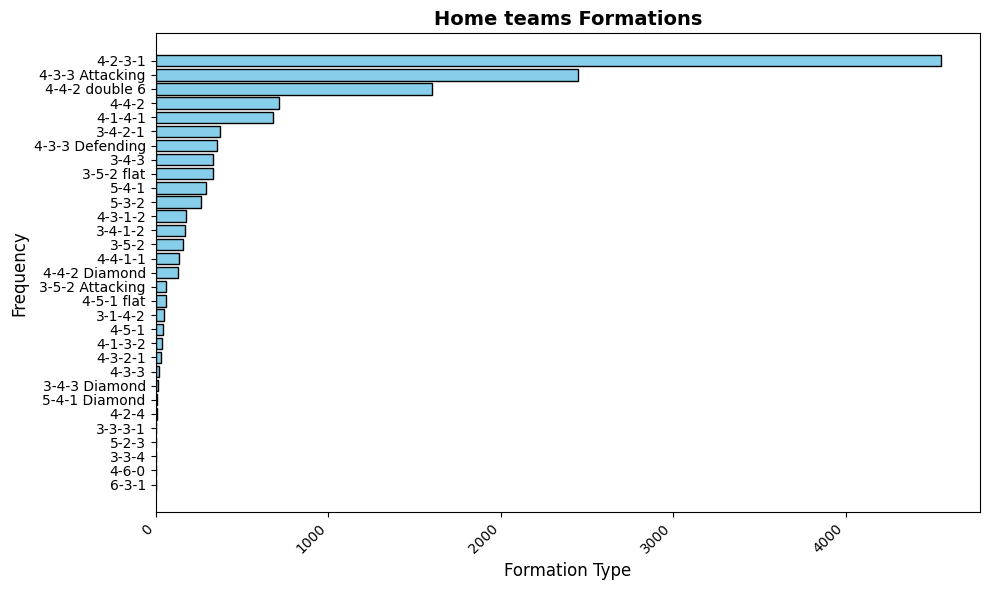

In [50]:
plt.figure(figsize=(10, 6))
plt.barh(home_formations.index, home_formations.values, color='skyblue', edgecolor='black')

plt.title('Home teams Formations', fontsize=14, fontweight='bold')
plt.xlabel('Formation Type', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

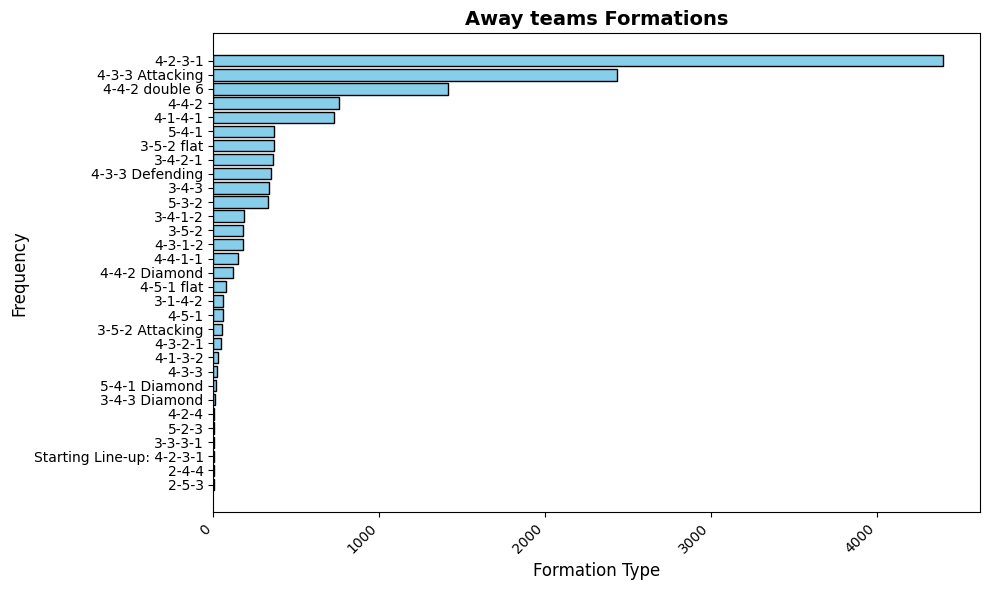

In [51]:
plt.figure(figsize=(10, 6))
plt.barh(away_formations.index, away_formations.values, color='skyblue', edgecolor='black')

plt.title('Away teams Formations', fontsize=14, fontweight='bold')
plt.xlabel('Formation Type', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

As I said above in the formations explanations, the more widely used ones are the `4-2-3-1` and the `4-3-3`, which are known as more balanced formation styles.However we can see that in some of the formations there are additional descriptions like: **Attcking, Defending, Diamond etc**.This explans the fact that even if the team is playing with more defensive or attcking type formation, there are specific hidden tactics which teams follow during the matches and these tactics are made so that they can confuse their opponents somehow!So the availability of these additional descriptions are very important for the features that we are going to make! 

#### I think that overall the data is sufficiently cleaned and ready for next the procedures.

This is what we have as a final cleaned target data:

In [52]:
target_games.info()

<class 'pandas.DataFrame'>
Index: 4180 entries, 12795 to 74773
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   game_id                 4180 non-null   int32         
 1   competition_id          4180 non-null   category      
 2   season                  4180 non-null   category      
 3   round                   4180 non-null   category      
 4   date                    4180 non-null   datetime64[us]
 5   home_club_id            4180 non-null   int32         
 6   away_club_id            4180 non-null   int32         
 7   home_club_goals         4180 non-null   int8          
 8   away_club_goals         4180 non-null   int8          
 9   home_club_position      4180 non-null   Int8          
 10  away_club_position      4180 non-null   Int8          
 11  home_club_manager_name  4180 non-null   category      
 12  away_club_manager_name  4180 non-null   category      
 13 

#### The only problematic thing is the missing values in the team's formations features but they will be handled when the datasets are merged into the `final data cleaning`!

And here is the final cleaned data, including all of the other competitions:

In [53]:
games_interim_df.info()

<class 'pandas.DataFrame'>
Index: 13788 entries, 12744 to 79211
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   game_id                 13788 non-null  int32         
 1   competition_id          13788 non-null  category      
 2   season                  13788 non-null  category      
 3   round                   13788 non-null  category      
 4   date                    13788 non-null  datetime64[us]
 5   home_club_id            13788 non-null  int32         
 6   away_club_id            13788 non-null  int32         
 7   home_club_goals         13788 non-null  int8          
 8   away_club_goals         13788 non-null  int8          
 9   home_club_position      4180 non-null   Int8          
 10  away_club_position      4180 non-null   Int8          
 11  home_club_manager_name  13720 non-null  category      
 12  away_club_manager_name  13720 non-null  category      
 13

### Next steps:

#### As this notebook became really long and we have a lot more things to be done, what I will do, is that I will create another notebook which will be specifically about the feature engineering!And now I will just save this cleaned version of the dataset into the interim folder and then in the next notebook I will start with the already cleaned and prepared data!

### Saving the dataset:

In [54]:
PROJECT_ROOT = Path().resolve().parent.parent

file_path = PROJECT_ROOT / TRANSFERMARKT_DATA_INTERIM_PATH
file_path.mkdir(parents=True, exist_ok=True)

In [55]:
PROJECT_ROOT = Path().resolve().parent.parent
file_path = PROJECT_ROOT / TRANSFERMARKT_DATA_INTERIM_PATH / 'interim_matches_v1.parquet'

save_data(data=games_interim_df, file_path=file_path)

The file has already been created and it contains the exact data as the original dataset!
